In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv("01-2024.csv")
df2 = pd.read_csv("02-2024.csv")
df3 = pd.read_csv("03-2024.csv")
df4 = pd.read_csv("04-2024.csv")
df5 = pd.read_csv("05-2024.csv")

In [5]:
df = pd.concat([df1,df2,df3,df4,df5], ignore_index=True)

In [7]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,45038097227,2024-01-02 08:45,NaN,00:01:09,NaN,Adrian Tran
1,45039043875,2024-01-02 09:15,Outbound,NaN,NaN,Robin Stoehr
2,45039334209,2024-01-02 09:19,Inbound,00:07:00,NaN,Robin Stoehr
3,45039342520,2024-01-02 09:27,NaN,00:01:05,NaN,Robin Stoehr
4,45039926394,2024-01-02 09:31,Outbound,00:01:18,NaN,Robin Stoehr
...,...,...,...,...,...,...
53200,53697387015,2024-05-31 20:15,Outbound,00:00:36,NaN,David Valdez
53201,53699213995,2024-05-31 20:15,Outbound,00:00:33,NaN,David Valdez
53202,53703066291,2024-05-31 22:34,Inbound,00:00:00,NaN,NaN
53203,53703608918,2024-05-31 22:50,Inbound,00:00:00,NaN,NaN


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 53205 entries, 0 to 53204
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         53205 non-null  str  
 1   Call direction        32546 non-null  str  
 2   Call duration         48996 non-null  str  
 3   Activity assigned to  52357 non-null  str  
dtypes: str(4)
memory usage: 3.7 MB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors = "coerce"
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 53205 entries, 0 to 53204
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         53205 non-null  datetime64[us]
 1   Call direction        32546 non-null  str           
 2   Call duration         48996 non-null  str           
 3   Activity assigned to  52357 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 2.9 MB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,2024-01-02
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,2024-01-02
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,2024-01-02
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,2024-01-02
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,2024-01-02


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [26]:
daily_calls.tail()

,date,call_count
146,2024-05-27,148
147,2024-05-28,332
148,2024-05-29,351
149,2024-05-30,409
150,2024-05-31,356


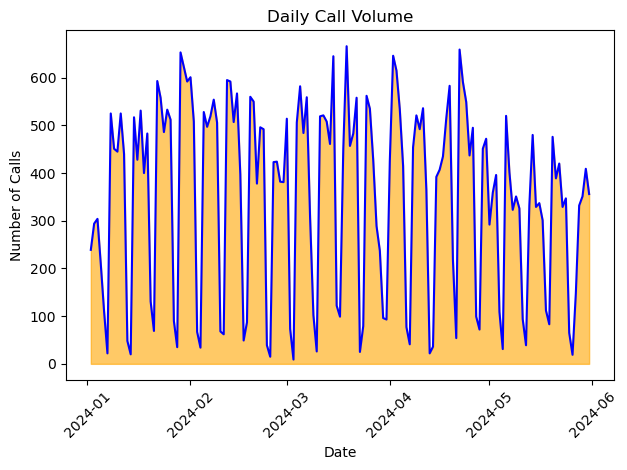

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color = 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr


# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

In [35]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,Tuesday
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,Tuesday
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,Tuesday
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,Tuesday


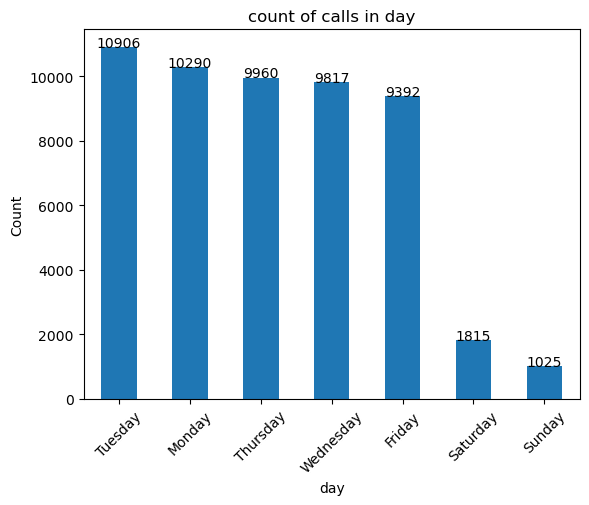

In [37]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

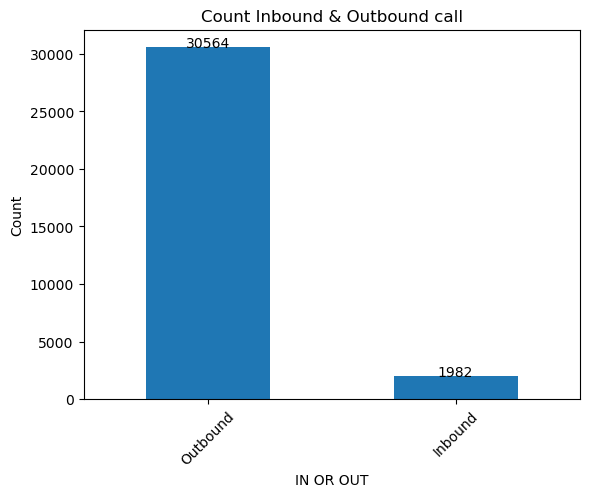

In [40]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [43]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

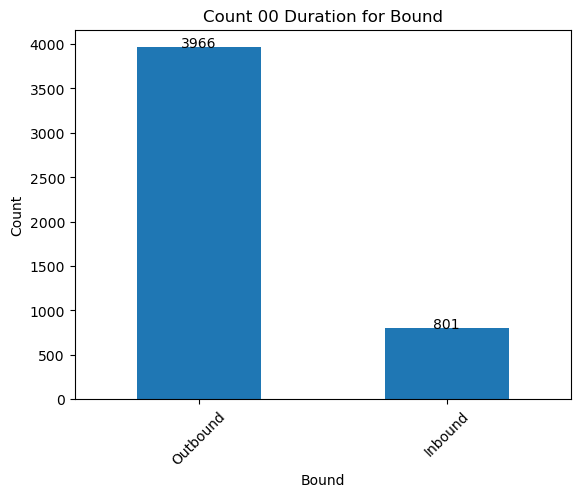

In [45]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call Duration NULL but have Call direction

In [48]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday
239,2024-01-03 09:04:00,Inbound,NaN,Robin Stoehr,Wednesday
246,2024-01-03 09:48:00,Outbound,NaN,Robin Stoehr,Wednesday
251,2024-01-03 10:20:00,Outbound,NaN,Robin Stoehr,Wednesday
425,2024-01-03 14:17:00,Outbound,NaN,Jinky Rance,Wednesday
...,...,...,...,...,...
51142,2024-05-23 17:52:00,Outbound,NaN,Cameron Dudley,Thursday
51250,2024-05-24 12:50:00,Outbound,NaN,Garrett Evans,Friday
51793,2024-05-28 10:54:00,Outbound,NaN,Cameron Dudley,Tuesday
52465,2024-05-30 11:15:00,Outbound,NaN,Cameron Dudley,Thursday


In [50]:
df4 = df1.copy()

In [52]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,Tuesday
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,Tuesday
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,Tuesday
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,Tuesday


In [54]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [56]:
(df4['Call duration'] == 0).sum()

4767

In [58]:
df4['Call duration'].isnull().sum()

4209

In [60]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 53205 entries, 0 to 53204
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         53205 non-null  datetime64[us]
 1   Call direction        32546 non-null  str           
 2   Call duration         48996 non-null  float64       
 3   Activity assigned to  52357 non-null  str           
 4   day                   53205 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 3.3 MB


In [62]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [64]:
df4 = df4.dropna(subset = ['Call direction'])

In [66]:
df4['Call duration'].isnull().sum()

0

In [68]:
df4['Call direction'].isnull().sum()

0

In [70]:
(df4['Call duration'] == 0).sum()

5254

In [72]:
df4.info()

<class 'pandas.DataFrame'>
Index: 32546 entries, 1 to 53204
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         32546 non-null  datetime64[us]
 1   Call direction        32546 non-null  str           
 2   Call duration         32546 non-null  float64       
 3   Activity assigned to  31749 non-null  str           
 4   day                   32546 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.3 MB


# Working Call Assigner

In [75]:
df1['Activity assigned to'].nunique()

29

In [77]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[           'Adrian Tran',           'Robin Stoehr',          'Keith Antonio',
         'Cameron Dudley',       'Vladimir Suparto',           'Dioni Canega',
            'Sal Berdayi',          'Oliver Martin',            'Jinky Rance',
           'Karen Parker',          'Sam Steindorf',           'Louis Maciel',
       'Chrystel Manabat',                      nan,           'David Valdez',
         'David Banister',            'Paol Guzman',          'Garrett Evans',
           'Ray Levesque',    'Demmie Rose Tamonan',        'Adonis Baybayan',
             'Henry Good',           'Bill Goodwin',              'Terry Kim',
              'Juan Calo',      'Brittany Digiulio',           'Stephen Tarr',
 'Jannica Nikka Antipuna',          'Tanner Schunk',             'Tyler Jury']
Length: 30, dtype: str

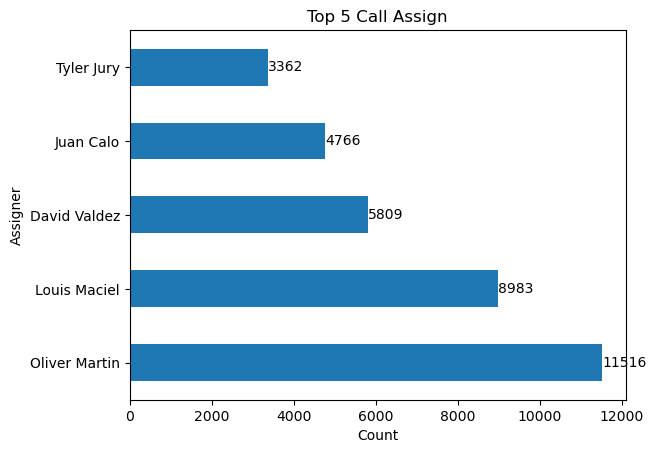

In [79]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION 

In [82]:
df4['Call duration'].max()

163.6

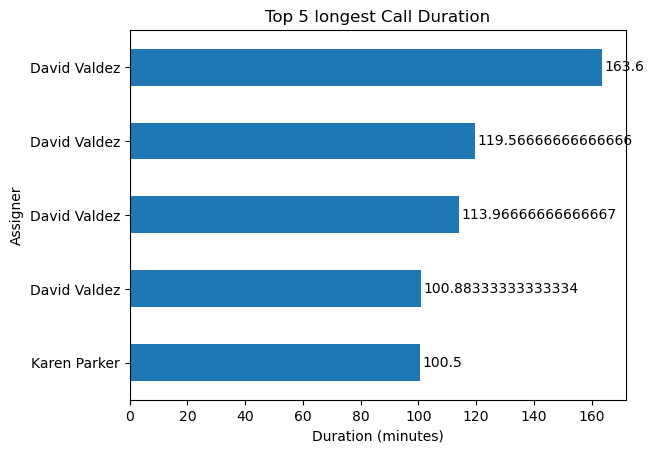

In [84]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [87]:
df3=df1.copy()

In [89]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [91]:
df3['day'].unique()

<ArrowStringArray>
['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Monday']
Length: 5, dtype: str

In [93]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

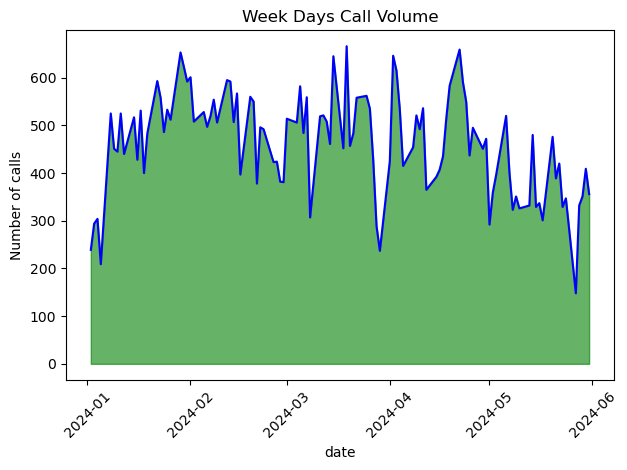

In [95]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [98]:
df5 = df4.copy()

In [100]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [102]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
12041,2024-02-04 00:51:00,Inbound,0.000000,NaN,Sunday
17481,2024-02-17 13:16:00,Outbound,0.000000,Oliver Martin,Saturday
17482,2024-02-17 13:18:00,Outbound,1.066667,Oliver Martin,Saturday
17516,2024-02-18 08:20:00,Inbound,0.000000,NaN,Sunday
17524,2024-02-18 11:34:00,Outbound,0.000000,Robin Stoehr,Sunday


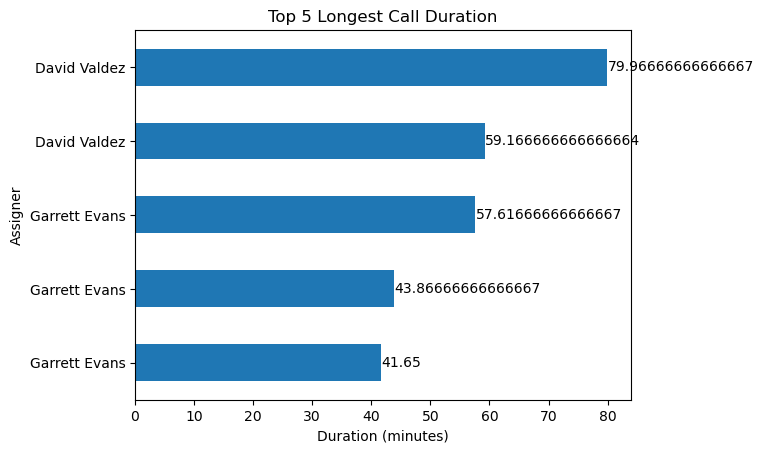

In [104]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

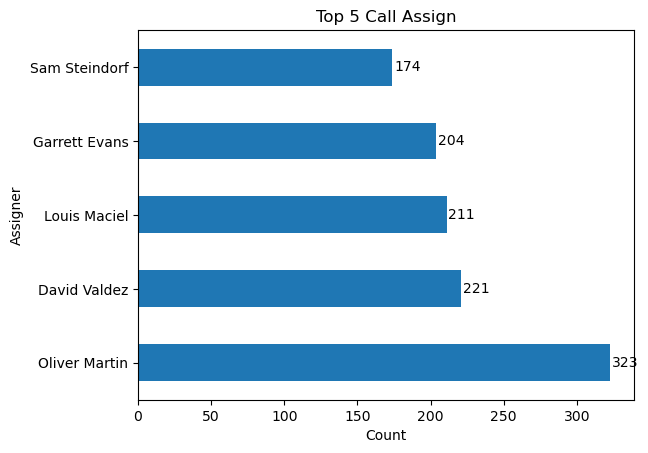

In [107]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [110]:
df6 = df3.copy()

In [112]:
df6['month'] = df6['Activity date'].dt.month_name()

In [114]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,Tuesday,January
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday,January
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,Tuesday,January
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,Tuesday,January
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,Tuesday,January


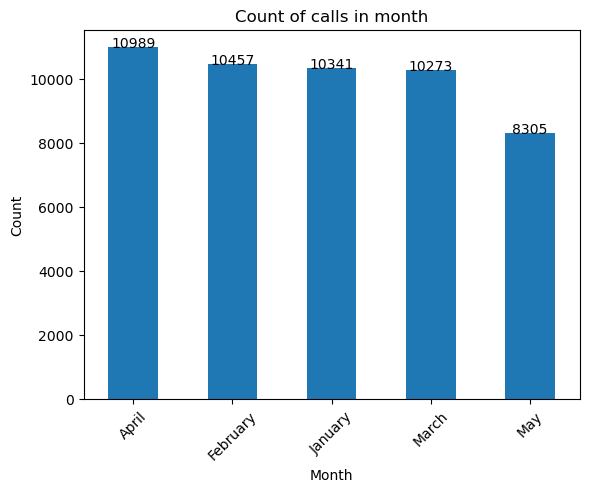

In [116]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Average Call Duration

In [120]:
df4["Call duration"].mean()

1.5556986009545466

In [122]:
df4["Call duration"].median()

0.23333333333333334

# Without Call Assigner Calls

In [125]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [127]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 791 entries, 594 to 53204
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         791 non-null    datetime64[us]
 1   Call direction        740 non-null    str           
 2   Call duration         791 non-null    str           
 3   Activity assigned to  0 non-null      str           
 4   day                   791 non-null    str           
 5   month                 791 non-null    str           
dtypes: datetime64[us](1), str(5)
memory usage: 64.3 KB


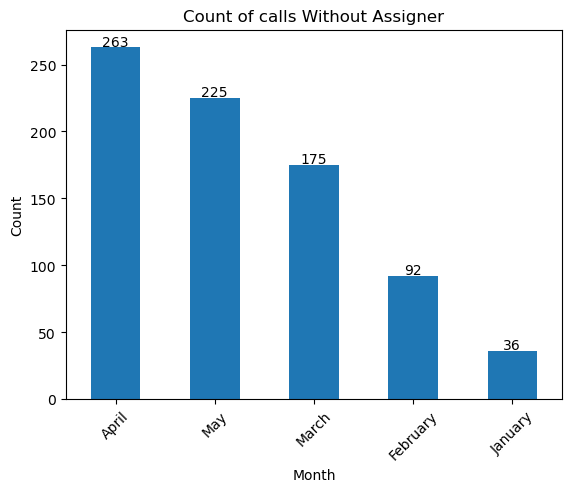

In [129]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [132]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [134]:
top5 = daily_calls.sort_values(ascending=False).head(5)

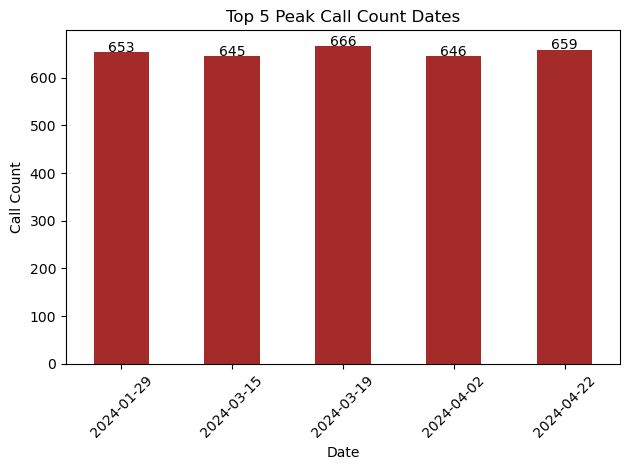

In [136]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()